# Source-Reconstructed Fixation ERP — Brain Visualisation

Loads pre-computed source ERPs (morphed to fsaverage) from the HPC share
and creates publication-quality brain plots.

**Workflow:**
1. Load per-subject morphed `.stc` files via SSH mount
2. Compute group average
3. Plot brain at chosen time points (lateral / medial, pial / inflated)
4. Save standalone colorbar

Run `compute_source_erp.py` on the HPC first to produce the `.stc` files.

**Author:** P. Sulewski (psulewski@uos.de)

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mne

sns.set_context('poster')
plt.rcParams['svg.fonttype'] = 'none'

print('Libraries loaded.')

Libraries loaded.


## Configuration

In [29]:
# ── Subject / analysis parameters ────────────────────────────────────────────
subjects    = [1, 2, 3, 4, 5]
event_type  = 'fixation'   # 'fixation' | 'saccade' | 'blink' | 'scene'
timing      = 'onset'      # 'onset' | 'offset'

# ── SSH-mount paths ──────────────────────────────────────────────────────────
avs_dir   = '/Users/atlas/avs'
share_dir = '/Users/atlas/share_psulewski/psulewski'

subjects_dir = f'{avs_dir}/rawdir/'          # FreeSurfer subjects dir
erp_dir      = f'{share_dir}/pyavs/source_erp/{event_type}/{timing}/'
morph_to     = 'fsaverage'                   # must exist in subjects_dir

# ── Output ───────────────────────────────────────────────────────────────────
output_dir = os.path.join('/Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/meg_viz', 'source_erp_figures',
                           event_type, timing)
os.makedirs(output_dir, exist_ok=True)

# ── Visualisation parameters ─────────────────────────────────────────────────
# Time points to visualise [seconds]
time_points = [0.114]

surfaces = ['pial']
views    = ['lateral', 'medial']

colormap = 'viridis'  # perceptually uniform sequential colormap

# Color limits (amplitude, starting from zero)
# Adjust vmax after inspecting the group average.
vmin = 0.0
vmid = None    # set to None → auto-set to midpoint of [vmin, vmax]
vmax = 775    # set to None → auto-set to 99th percentile of group average

print(f'Event: {event_type} ({timing})')
print(f'Subjects: {subjects}')
print(f'ERP dir: {erp_dir}')
print(f'Output:  {output_dir}')

Event: fixation (onset)
Subjects: [1, 2, 3, 4, 5]
ERP dir: /Users/atlas/share_psulewski/psulewski/pyavs/source_erp/fixation/onset/
Output:  /Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/meg_viz/source_erp_figures/fixation/onset


## Function Definitions

In [30]:
def load_subject_stc(subject_id, erp_dir, event_type, timing):
    """Load a morphed source ERP for one subject."""
    fname = os.path.join(
        erp_dir,
        f'sub-{subject_id:02d}_task-avs_{event_type}_{timing}_erp'
    )
    # MNE appends -lh.stc / -rh.stc automatically
    if not (os.path.exists(fname + '-lh.stc') and
            os.path.exists(fname + '-rh.stc')):
        print(f'  WARNING: STC not found for sub-{subject_id:02d} — skipping.')
        return None
    stc = mne.read_source_estimate(fname)
    print(f'  sub-{subject_id:02d}: {stc.data.shape[0]} vertices, '
          f'{stc.data.shape[1]} time points, '
          f'tmin={stc.tmin*1000:.0f} ms')
    return stc


def compute_group_average(stcs):
    """Average source estimates across subjects (list of SourceEstimate)."""
    data_stack = np.stack([s.data for s in stcs], axis=0)   # (n_subs, n_verts, n_times)
    avg_data   = np.mean(data_stack, axis=0)
    avg_stc    = stcs[0].copy()
    avg_stc.data = avg_data
    return avg_stc


def auto_clim(stc, vmin=0.0, quantile=0.99):
    """Derive color limits from the group-average STC if not specified."""
    vmax = float(np.quantile(stc.data, quantile))
    vmid = (vmin + vmax) / 2
    return vmin, vmid, vmax


def plot_brain(
    stc, time_point, surface, view,
    subjects_dir, morph_to, colormap,
    vmin, vmid, vmax,
    save_path=None,
):
    """
    Render a brain plot at one time point and optionally save it.

    Parameters
    ----------
    stc : mne.SourceEstimate
        Group-average source estimate
    time_point : float
        Time to display [s]
    surface : str
        'pial' or 'inflated'
    view : str
        'lateral' or 'medial'
    subjects_dir : str
        FreeSurfer subjects directory
    morph_to : str
        Subject name (must exist in subjects_dir)
    colormap : str
        MNE-compatible colormap name
    vmin, vmid, vmax : float
        Color limits for the colorbar
    save_path : str or None
        Full file path (without extension) to save PNG

    Returns
    -------
    mne.viz.Brain
    """
    brain = stc.plot(
        subject=morph_to,
        subjects_dir=subjects_dir,
        initial_time=time_point,
        hemi='split',
        time_viewer=False,
        colorbar=False,
        colormap=colormap,
        clim=dict(kind='value', lims=[vmin, vmid, vmax]),
        smoothing_steps=3,
        transparent=False,
        surface=surface,
        background='white',
        views=view,
        size=(900, 450),
    )

    if save_path:
        brain.save_image(save_path + '.png')
        print(f'    Saved: {os.path.basename(save_path)}.png')

    return brain


def create_colorbar(vmin, vmid, vmax, colormap, output_dir, label='amplitude [a.u.]'):
    """
    Save a standalone horizontal colorbar figure.

    The colorbar is rendered without a frame and with lowercase axis label,
    consistent with CLAUDE.md style guidelines.
    """
    plt.figure(figsize=(5.5, 3.4))
    ax = plt.gca()

    mne.viz.plot_brain_colorbar(
        ax,
        clim=dict(kind='value', lims=[vmin, vmid, vmax]),
        colormap=colormap,
        transparent=False,
        orientation='horizontal',
    )

    ticks = np.linspace(vmin, vmax, 3)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f'{t:.0f}' for t in ticks])
    ax.set_xlabel(label)
    ax.tick_params(tick1On=False)

    sns.despine()
    plt.tight_layout()

    for ext in ('png', 'pdf'):
        fpath = os.path.join(output_dir, f'colorbar.{ext}')
        plt.savefig(fpath, dpi=300, bbox_inches='tight',
                    facecolor='white', edgecolor='none')
    plt.show()
    print(f'Colorbar saved to {output_dir}')


print('Functions defined.')

Functions defined.


## Load Per-Subject STCs

In [31]:
print(f'Loading STCs from: {erp_dir}\n')

stcs = []
loaded_subjects = []

for sub in subjects:
    stc = load_subject_stc(sub, erp_dir, event_type, timing)
    if stc is not None:
        stcs.append(stc)
        loaded_subjects.append(sub)

print(f'\nLoaded {len(stcs)}/{len(subjects)} subjects: {loaded_subjects}')

Loading STCs from: /Users/atlas/share_psulewski/psulewski/pyavs/source_erp/fixation/onset/

  sub-01: 20484 vertices, 351 time points, tmin=-200 ms
  sub-02: 20484 vertices, 351 time points, tmin=-200 ms
  sub-03: 20484 vertices, 351 time points, tmin=-200 ms
  sub-04: 20484 vertices, 351 time points, tmin=-200 ms
  sub-05: 20484 vertices, 351 time points, tmin=-200 ms

Loaded 5/5 subjects: [1, 2, 3, 4, 5]


## Group Average

In [32]:
if not stcs:
    raise RuntimeError('No STCs loaded — check erp_dir and run compute_source_erp.py first.')

avg_stc = compute_group_average(stcs)

print(f'Group average shape: {avg_stc.data.shape}')
print(f'Time range: {avg_stc.tmin*1000:.0f} – {avg_stc.times[-1]*1000:.0f} ms')
print(f'Amplitude range: {np.abs(avg_stc.data).min():.3e} – {np.abs(avg_stc.data).max():.3e}')

# Resolve color limits
if vmax is None:
    _vmin, _vmid, _vmax = auto_clim(avg_stc, vmin=vmin)
    print(f'\nAuto color limits: vmin={_vmin:.3e}, vmid={_vmid:.3e}, vmax={_vmax:.3e}')
else:
    _vmin = vmin
    _vmid = vmid if vmid is not None else (vmin + vmax) / 2
    _vmax = vmax
    print(f'\nManual color limits: vmin={_vmin:.3e}, vmid={_vmid:.3e}, vmax={_vmax:.3e}')

Group average shape: (20484, 351)
Time range: -200 – 500 ms
Amplitude range: 2.502e+00 – 2.532e+03

Manual color limits: vmin=0.000e+00, vmid=3.875e+02, vmax=7.750e+02


## Brain Plots

Generates one image per `(time_point, surface, view)` combination.

In [33]:
print('Generating brain plots...\n')

for t in time_points:
    t_ms = int(round(t * 1000))
    print(f'Time point: {t_ms} ms')

    for surface in surfaces:
        for view in views:
            fname = (
                f'{event_type}_{timing}'
                f'_t{t_ms:03d}ms'
                f'_{surface}_{view}'
            )
            save_path = os.path.join(output_dir, fname)

            try:
                brain = plot_brain(
                    stc=avg_stc,
                    time_point=t,
                    surface=surface,
                    view=view,
                    subjects_dir=subjects_dir,
                    morph_to=morph_to,
                    colormap=colormap,
                    vmin=_vmin, vmid=_vmid, vmax=_vmax,
                    save_path=save_path,
                )
                brain.close()
            except Exception as e:
                print(f'  ERROR ({surface}, {view}, {t_ms} ms): {e}')

print('\nBrain plots done.')

Generating brain plots...

Time point: 114 ms
    Saved: fixation_onset_t114ms_pial_lateral.png
    Saved: fixation_onset_t114ms_pial_medial.png

Brain plots done.


## Standalone Colorbar

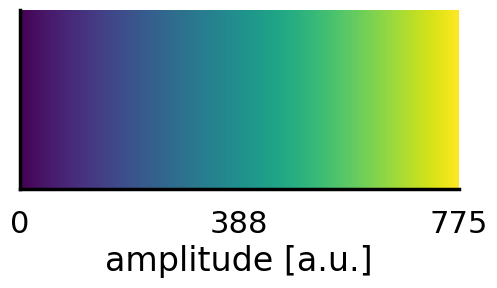

Colorbar saved to /Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/meg_viz/source_erp_figures/fixation/onset


In [34]:
create_colorbar(
    vmin=_vmin,
    vmid=_vmid,
    vmax=_vmax,
    colormap=colormap,
    output_dir=output_dir,
    label='amplitude [a.u.]',
)

## Quick Time-Course Check (optional)

Sensor-space–style summary: mean absolute source amplitude across all vertices over time.  
Useful for verifying the ERP is sensible before committing to the full brain render.

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


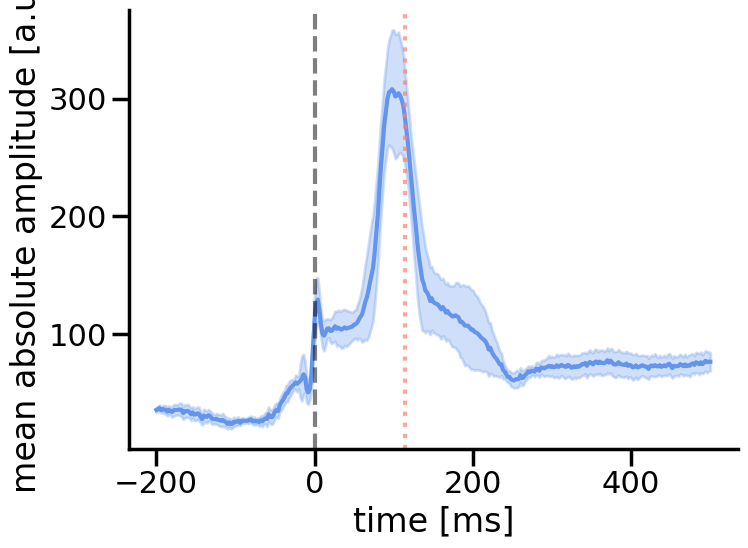

Time-course saved: /Users/atlas/Documents/Documents_atlas/PhD/code/pyavs_conversion/pyavs/scripts/meg_viz/source_erp_figures/fixation/onset/fixation_onset_source_timecourse.png


In [35]:
times_ms  = avg_stc.times * 1000
mean_amp  = np.median(np.abs(avg_stc.data), axis=0)
sem_amp   = np.std(np.stack(
    [np.mean(np.abs(s.data), axis=0) for s in stcs], axis=0
), axis=0) / np.sqrt(len(stcs))

plt.figure(figsize=(8, 6))
plt.plot(times_ms, mean_amp, color='cornflowerblue')
plt.fill_between(
    times_ms,
    mean_amp - sem_amp,
    mean_amp + sem_amp,
    color='cornflowerblue', alpha=0.3,
)
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
for t in time_points:
    plt.axvline(x=t * 1000, color='salmon', linestyle=':', alpha=0.7)
plt.xlabel('time [ms]')
plt.ylabel('mean absolute amplitude [a.u.]')
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()

tc_path = os.path.join(output_dir, f'{event_type}_{timing}_source_timecourse')
for ext in ('png', 'pdf'):
    plt.savefig(f'{tc_path}.{ext}', dpi=300, bbox_inches='tight',
                facecolor='white', edgecolor='none')
plt.show()
print(f'Time-course saved: {tc_path}.png')